<a href="https://colab.research.google.com/github/Jeffrey-AI-research/Stock-Market-Predictions-AI-Research/blob/main/Stock_Market_Predictions_AI_Research_(TS_ARIMA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ARIMA Time-Series Models

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
cumulative_df = pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Major%20Tech%20Stocks%202019-2024%20Dataset/major-tech-stock-2019-2024.csv")
cumulative_df["Date"] = pd.to_datetime(cumulative_df["Date"])
cumulative_df = cumulative_df.sort_values(["Ticker", "Date"])
all_actual = []
all_predictions = []
company_results = []
company_forecasts = {}

for ticker in cumulative_df["Ticker"].unique():
    company = cumulative_df[cumulative_df["Ticker"] == ticker].copy().reset_index(drop=True)
    for lag in range(1,6):
        company[f"Close_Lag_{lag}"] = company["Close"].shift(lag)

    company = company.dropna().reset_index(drop=True)
    features = [f"Close_Lag_{lag}" for lag in range(1,6)]
    split_index = int(len(company) * 0.8)
    train = company.iloc[:split_index]
    test = company.iloc[split_index:]
    cumulative_model = LinearRegression()
    cumulative_model.fit(train[features], train["Close"])
    history = train["Close"].tolist()
    predictions = []

    for i in range(len(test)):
        model_input = pd.DataFrame([history[-5:][::-1]], columns=features)
        prediction = cumulative_model.predict(model_input)[0]
        predictions.append(prediction)
        history.append(prediction)

    actual = test["Close"].to_numpy()
    company_results.append({"Ticker": ticker,"MAE": mean_absolute_error(actual, predictions),"RMSE": np.sqrt(mean_squared_error(actual, predictions)),"R²": r2_score(actual, predictions)})
    all_actual.extend(actual)
    all_predictions.extend(predictions)
    company_forecasts[ticker] = {"Dates": test["Date"],"Actual": actual,"Predicted": predictions}

cumulative_results = pd.DataFrame(company_results)
print("Cumulative Results by Company")
print(cumulative_results.round(3))
print("\nCombined Cumulative Results")
print("R²:", r2_score(all_actual, all_predictions))
print("MAE:", mean_absolute_error(all_actual, all_predictions))
print("RMSE:", np.sqrt(mean_squared_error(all_actual, all_predictions)))

Cumulative Results by Company
  Ticker     MAE    RMSE     R²
0   AAPL  38.504  41.438 -4.626
1   AMZN  20.374  23.452 -0.528
2  GOOGL  25.606  29.096 -2.218
3   MSFT  67.437  76.685 -2.485
4   TSLA  74.671  82.052 -2.786

Combined Cumulative Results
R²: 0.4850007148830612
MAE: 45.31858362586014
RMSE: 56.08351526769248


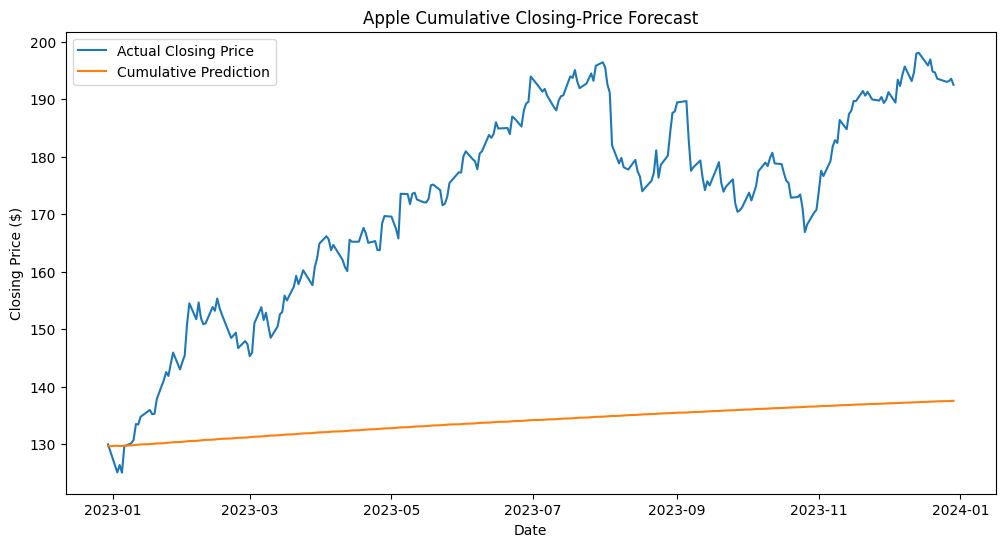

In [ ]:
ticker = "AAPL"
forecast = company_forecasts[ticker]
plt.figure(figsize=(12,6))
plt.plot(forecast["Dates"], forecast["Actual"], label="Actual Closing Price")
plt.plot(forecast["Dates"], forecast["Predicted"], label="Cumulative Prediction")
plt.title("Apple Cumulative Closing-Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()

plt.savefig("apple_cumulative_forecast.png", dpi=300, bbox_inches="tight")
plt.show()